# Credit Risk Scoring — Exploratory Data Analysis

This notebook explores three datasets provided for the Data Science Nigeria Credit Risk Prediction challenge:

- **trainperf** — one row per current loan. Contains our target variable `good_bad_flag` (Good/Bad).
- **trainprevloans** — multiple rows per customer, representing previous loan history.
- **traindemographics** — one row per customer, containing demographics and GPS coordinates.

The goal of this EDA is to understand the data, identify quality issues, engineer meaningful features, and determine which variables are most predictive of loan default.

## 1. Setup & Data Loading

In [833]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [835]:
trainperf = pd.read_csv(r"C:\Users\ik\Downloads\data-science-nigeria-credit-risk-prediction\trainperf.csv")
trainprev = pd.read_csv(r"C:\Users\ik\Downloads\data-science-nigeria-credit-risk-prediction\trainprevloans.csv")
traindemo = pd.read_csv(r"C:\Users\ik\Downloads\data-science-nigeria-credit-risk-prediction\traindemographics.csv")

for name, df in [("trainperf", trainperf), ("trainprev", trainprev), ("traindemo", traindemo)]:
    print(f"=== {name} ===")
    print(df.shape)
    print(df.dtypes)
    display(df.head())

=== trainperf ===
(4368, 10)
customerid        object
systemloanid       int64
loannumber         int64
approveddate      object
creationdate      object
loanamount       float64
totaldue         float64
termdays           int64
referredby        object
good_bad_flag     object
dtype: object


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good


=== trainprev ===
(18183, 12)
customerid          object
systemloanid         int64
loannumber           int64
approveddate        object
creationdate        object
loanamount         float64
totaldue           float64
termdays             int64
closeddate          object
referredby          object
firstduedate        object
firstrepaiddate     object
dtype: object


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


=== traindemo ===
(4346, 9)
customerid                     object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
dtype: object


,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


In [836]:
# Checking for duplicates
trainprev.duplicated().sum()

0

In [837]:
traindemo.duplicated().sum()


12

In [838]:
trainperf.duplicated().sum()

0

## 2. Data Preparation

In [840]:
# Convert date columns to datetime, and good_bad_flag to a binary flag.

date_cols_perf = ["approveddate", "creationdate"]
date_cols_prev = ["approveddate", "creationdate", "closeddate", "firstduedate", "firstrepaiddate"]
date_cols_demo = ["birthdate"]

for col in date_cols_perf:
    trainperf[col] = pd.to_datetime(trainperf[col])

for col in date_cols_prev:
    trainprev[col] = pd.to_datetime(trainprev[col])

for col in date_cols_demo:
    traindemo[col] = pd.to_datetime(traindemo[col])

trainperf["bad_flag"] = (trainperf["good_bad_flag"] == "Bad").astype(int)
trainperf["good_flag"] = (trainperf["good_bad_flag"] == "Good").astype(int)

In [841]:
# drop duplicate rows in traindemo (12 found)
traindemo.drop_duplicates(inplace=True)
print(f"traindemo after dedup: {traindemo.shape}")

traindemo after dedup: (4334, 9)


**Note:** `traindemo` contained 12 fully duplicated rows which were removed. `trainperf` and `trainprev` had no duplicates.

## 3. Data Quality Audit

### 3.1 Missing Values

In [844]:
# MISSING VALUE ANALYSIS

def missing_summary(df, name):
    total = df.shape[0]
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    summary = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": pct
    }).query("missing_count > 0").sort_values("missing_pct", ascending=False)
    print(f"\n=== {name} ({total} rows) ===")
    print(summary.to_string())
    return summary

miss_perf  = missing_summary(trainperf, "trainperf")
miss_prev  = missing_summary(trainprev, "trainprev")
miss_demo  = missing_summary(traindemo, "traindemographics")


=== trainperf (4368 rows) ===
            missing_count  missing_pct
referredby           3781        86.56

=== trainprev (18183 rows) ===
            missing_count  missing_pct
referredby          17157        94.36

=== traindemographics (4334 rows) ===
                            missing_count  missing_pct
bank_branch_clients                  4283        98.82
level_of_education_clients           3748        86.48
employment_status_clients             648        14.95


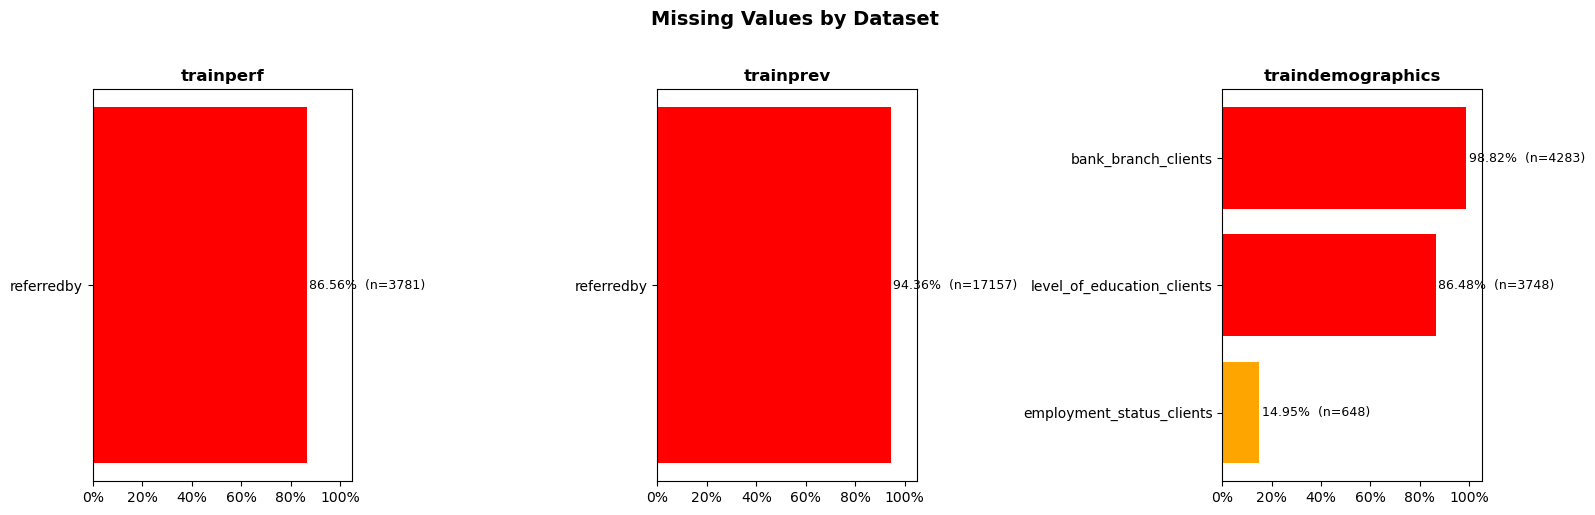

In [845]:
# VISUALZ/PLOT OF MISSING VALUE ANALYSIS 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Missing Values by Dataset", fontsize=14, fontweight="bold", y=1.02)

datasets = [
    (miss_perf,  "trainperf",          axes[0]),
    (miss_prev,  "trainprev",          axes[1]),
    (miss_demo,  "traindemographics",  axes[2]),
]

for summary, name, ax in datasets:
    if summary.empty:
        ax.set_title(f"{name}\n(no missing values)")
        ax.axis("off")
        continue

    colors = [
        "green" if p < 5 else "orange" if p < 30 else "red"
        for p in summary["missing_pct"]
    ]

    ax.barh(summary.index, summary["missing_pct"], color=colors)
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(name, fontweight="bold")
    ax.invert_yaxis()

    # label each bar
    for i, (pct, cnt) in enumerate(zip(summary["missing_pct"], summary["missing_count"])):
        ax.text(pct + 1, i, f"{pct}%  (n={cnt})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 3.2 Missing Value Actions

| Column | Missing % | Action | Reason |
|---|---|---|---|
| `referredby` (both tables) | 87–94% | Convert to binary `was_referred` flag | Whether referred is the signal, not who referred |
| `bank_branch_clients` | 99% | Drop entirely | Only 51 rows have data — unusable |
| `employment_status_clients` | 15% | Fill with "Unknown" | Too ambiguous to impute; Unknown becomes its own category |
| `level_of_education_clients` | 86% | Fill with "Unknown" | 14% who have it may still show a pattern worth capturing |

In [847]:
# referredby → binary was_referred flag
trainperf["was_referred"] = trainperf["referredby"].notna().astype(int)
trainprev["was_referred"] = trainprev["referredby"].notna().astype(int)

# bank_branch_clients → drop (99% missing)
traindemo.drop(columns=["bank_branch_clients"], inplace=True)

# fill remaining categoricals with "Unknown"
traindemo["employment_status_clients"] = traindemo["employment_status_clients"].fillna("Unknown")
traindemo["level_of_education_clients"] = traindemo["level_of_education_clients"].fillna("Unknown")

# confirm
print("was_referred distribution (trainperf):")
print(trainperf["was_referred"].value_counts())
print("\nemployment_status nulls remaining :", traindemo["employment_status_clients"].isnull().sum())
print("education nulls remaining         :", traindemo["level_of_education_clients"].isnull().sum())
print("bank_branch_clients still exists  :", "bank_branch_clients" in traindemo.columns)

was_referred distribution (trainperf):
was_referred
0    3781
1     587
Name: count, dtype: int64

employment_status nulls remaining : 0
education nulls remaining         : 0
bank_branch_clients still exists  : False


In [848]:
print(trainperf.groupby("was_referred")["bad_flag"].agg(
    default_rate="mean", count="count"
))

              default_rate  count
was_referred                     
0                 0.216345   3781
1                 0.228279    587


## 4. Target Variable — Class Imbalance

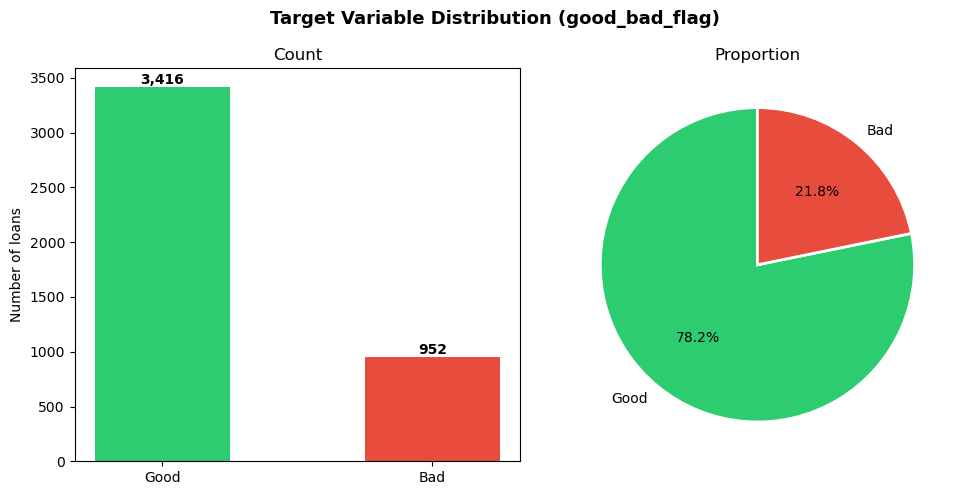


Good loans     : 3,416  (78.2%)
Bad loans      : 952  (21.8%)
Imbalance ratio: 3.6:1


In [850]:
target_counts = trainperf["good_bad_flag"].value_counts()
target_pct    = trainperf["good_bad_flag"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Target Variable Distribution (good_bad_flag)", fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(target_counts.index, target_counts.values, color=colors, width=0.5)
axes[0].set_title("Count")
axes[0].set_ylabel("Number of loans")
for i, (label, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 30, f"{val:,}", ha="center", fontweight="bold")

axes[1].pie(
    target_pct.values,
    labels=target_pct.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proportion")

plt.tight_layout()
plt.show()

print(f"\nGood loans     : {target_counts['Good']:,}  ({target_pct['Good']:.1f}%)")
print(f"Bad loans      : {target_counts['Bad']:,}  ({target_pct['Bad']:.1f}%)")
print(f"Imbalance ratio: {target_counts['Good'] / target_counts['Bad']:.1f}:1")

**Finding:** The dataset is imbalanced at roughly 3.6:1 (Good:Bad). A naive model that predicts "Good" for every loan would achieve ~78% accuracy — which sounds good but is completely useless for catching defaulters. This means:
- **Accuracy is the wrong metric** — we will use ROC-AUC, Precision-Recall, and F1 instead
- At modeling time, we will address this via **class weights** or **SMOTE** (synthetic oversampling)

## 5. Univariate EDA — Current Loans (trainperf)

In [853]:
# Univariate EDA on current loans (trainperf)

numeric_cols_perf = ["loanamount", "totaldue", "termdays"]
trainperf[numeric_cols_perf].describe()

,loanamount,totaldue,termdays
count,4368.000000,4368.000000,4368.000000
mean,17809.065934,21257.377679,29.261676
std,10749.694571,11943.510416,11.512519
min,10000.000000,10000.000000,15.000000
25%,10000.000000,13000.000000,30.000000
50%,10000.000000,13000.000000,30.000000
75%,20000.000000,24500.000000,30.000000
max,60000.000000,68100.000000,90.000000


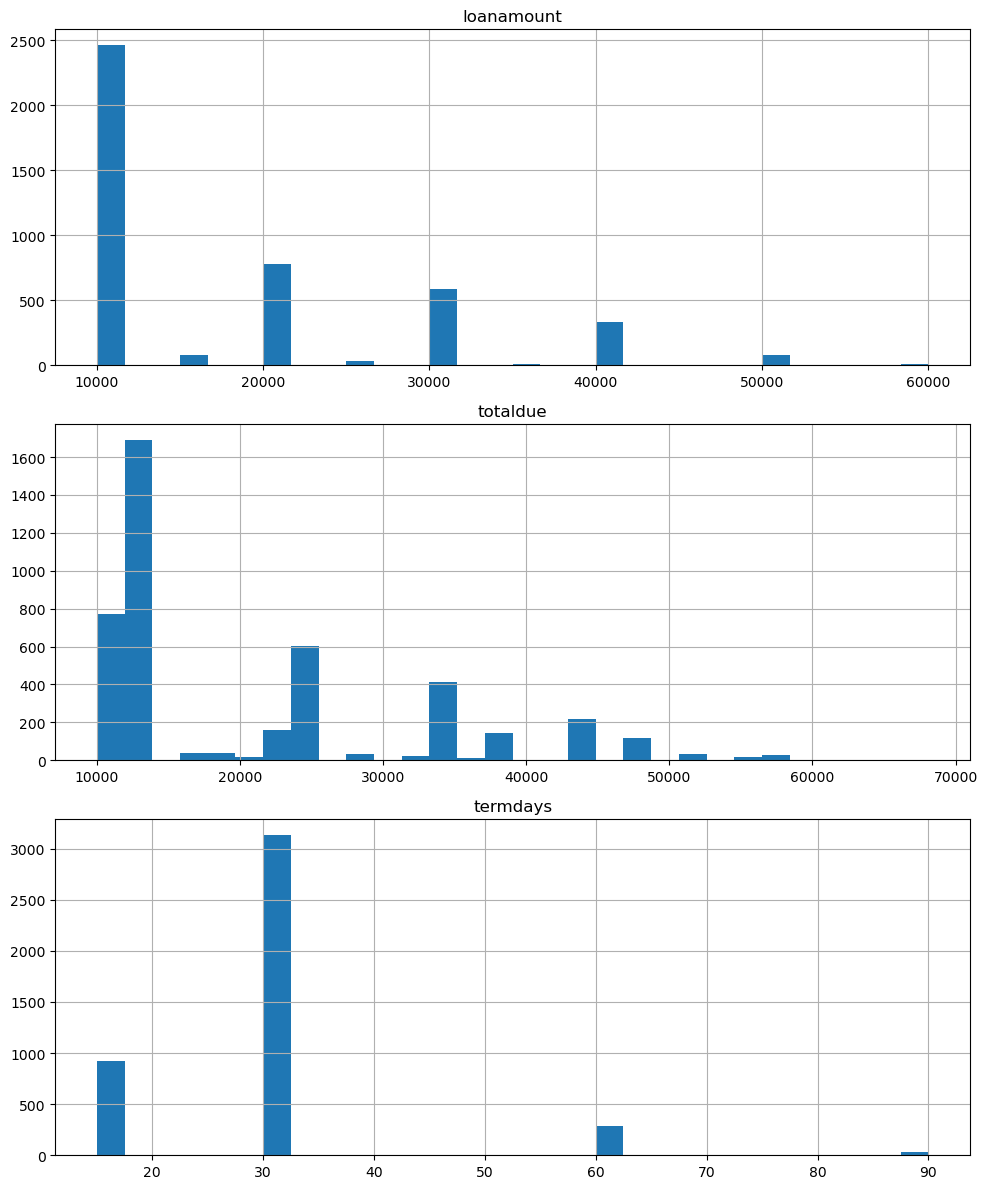

In [858]:
# HISTOGRAM

trainperf[numeric_cols_perf].hist(
    bins=30,
    figsize=(10, 12),  # taller to accommodate stacked charts
    layout=(3, 1)      # 3 rows, 1 column
)
plt.tight_layout()
plt.show()

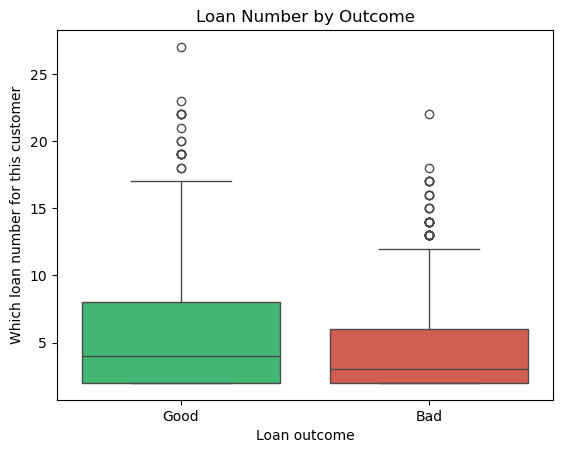

                count  mean  std  min  25%  50%  75%   max
good_bad_flag                                             
Bad             952.0   4.5  3.3  2.0  2.0  3.0  6.0  22.0
Good           3416.0   5.3  3.7  2.0  2.0  4.0  8.0  27.0


In [859]:
sns.boxplot(data=trainperf, x="good_bad_flag", y="loannumber",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False)
plt.title("Loan Number by Outcome")
plt.xlabel("Loan outcome")
plt.ylabel("Which loan number for this customer")
plt.show()

print(trainperf.groupby("good_bad_flag")["loannumber"].describe().round(1))

In [860]:
# time window of the dataset
print("approveddate :", trainperf["approveddate"].min(), "->", trainperf["approveddate"].max())
print("creationdate :", trainperf["creationdate"].min(), "->", trainperf["creationdate"].max())

approveddate : 2017-07-01 01:35:26 -> 2017-07-30 22:55:51
creationdate : 2017-07-01 00:35:20 -> 2017-07-30 21:55:43


All three numeric distributions are right-skewed — most loans cluster at lower values with a long tail of larger amounts. Loan amounts range from ~₦10,000 to ₦60,000. Term days cluster heavily at 30 days, with a secondary peak at 60 days, reflecting standardized product offerings. The dataset covers loans approved between **2016 and 2018**.

## 6. Numeric Features vs Default

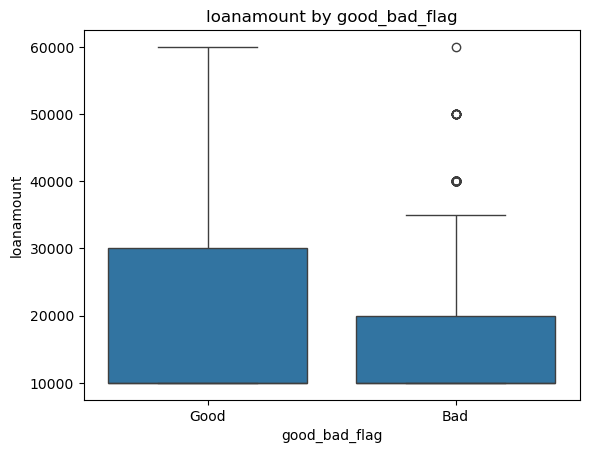

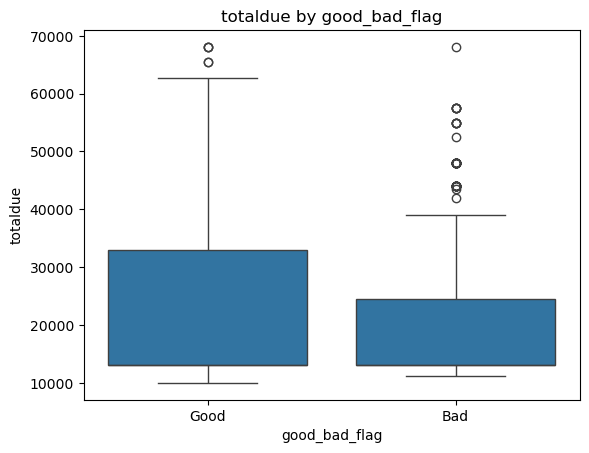

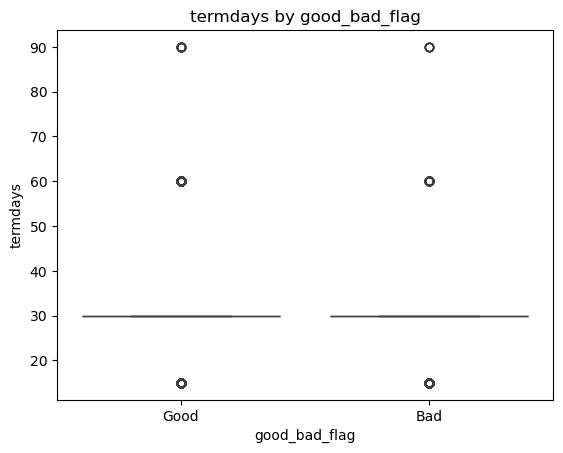

In [863]:
# Numeric vs Target

for col in numeric_cols_perf:
    sns.boxplot(data=trainperf, x="good_bad_flag", y=col)
    plt.title(f"{col} by good_bad_flag")
    plt.show()

In [864]:
## Correlation with bad_flag

corr = trainperf[numeric_cols_perf + ["bad_flag"]].corr()
corr["bad_flag"].sort_values(ascending=False)

bad_flag      1.000000
termdays     -0.005160
totaldue     -0.108357
loanamount   -0.115267
Name: bad_flag, dtype: float64

**Finding:** `loanamount`, `totaldue`, and `termdays` show minimal separation between Good and Bad borrowers — the boxplots heavily overlap. Correlations with `bad_flag` are all below 0.05. These raw loan features carry very little predictive signal on their own; engineered features built from them (like `interest_rate`) perform better.

## 7. Feature Engineering

count    4368.000000
mean        0.000229
std         0.015131
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: approval_lag_days, dtype: float64

Negative values (data issue): 0


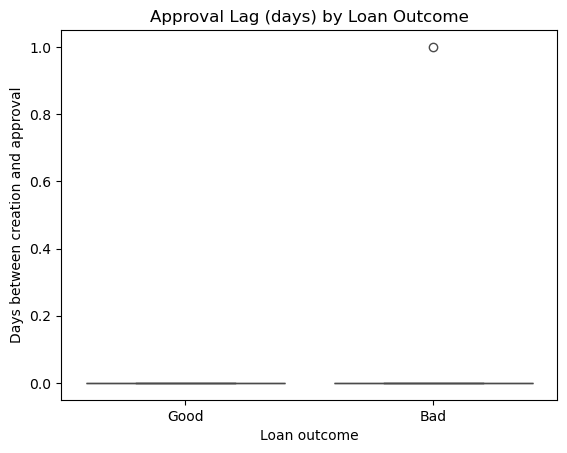

In [870]:
# interest charged (absolute)
trainperf["interest"] = trainperf["totaldue"] - trainperf["loanamount"]

# interest rate (proportional)
trainperf["interest_rate"] = trainperf["interest"] / trainperf["loanamount"]

# approval lag — days between loan creation and approval
trainperf["approval_lag_days"] = (trainperf["approveddate"] - trainperf["creationdate"]).dt.days

print(trainperf["approval_lag_days"].describe())
print("\nNegative values (data issue):", (trainperf["approval_lag_days"] < 0).sum())

sns.boxplot(data=trainperf, x="good_bad_flag", y="approval_lag_days",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False)
plt.title("Approval Lag (days) by Loan Outcome")
plt.xlabel("Loan outcome")
plt.ylabel("Days between creation and approval")
plt.show()

**Note:** `approval_lag_days` has near-zero variance — 75th percentile = 0 days, max = 1 day. Loans are approved same-day almost universally in this dataset, meaning this feature carries no predictive signal and will be dropped before modeling.

## 8. Previous Loans — Feature Engineering

In [873]:
# compute repayment delay per loan (positive = late, negative = early)
trainprev["repayment_delay_days"] = (
    pd.to_datetime(trainprev["firstrepaiddate"]) -
    pd.to_datetime(trainprev["firstduedate"])
).dt.days

# aggregate per customer
agg_prev = trainprev.groupby("customerid").agg(
    prev_loans_count        = ("systemloanid",          "nunique"),
    prev_total_loanamount   = ("loanamount",             "sum"),
    prev_max_loanamount     = ("loanamount",             "max"),
    prev_avg_loanamount     = ("loanamount",             "mean"),
    prev_avg_termdays       = ("termdays",               "mean"),
    avg_repayment_delay     = ("repayment_delay_days",   "mean"),
    max_repayment_delay     = ("repayment_delay_days",   "max"),
    pct_late_repayments     = ("repayment_delay_days",   lambda x: (x > 0).mean()),
)

# recency — date of last closed previous loan
last_closed = trainprev.groupby("customerid")["closeddate"].max().rename("prev_last_closeddate")
agg_prev = agg_prev.join(last_closed, on="customerid")

print(agg_prev[["avg_repayment_delay", "max_repayment_delay", "pct_late_repayments"]].describe().round(2))
print("\nNaN in repayment features:")
print(agg_prev[["avg_repayment_delay", "max_repayment_delay", "pct_late_repayments"]].isnull().sum())

       avg_repayment_delay  max_repayment_delay  pct_late_repayments
count              4359.00              4359.00              4359.00
mean                 -2.45                 2.80                 0.18
std                   7.41                15.12                 0.30
min                 -32.00               -32.00                 0.00
25%                  -5.50                -2.00                 0.00
50%                  -2.40                 0.00                 0.00
75%                   0.00                 4.00                 0.29
max                 121.00               351.00                 1.00

NaN in repayment features:
avg_repayment_delay    0
max_repayment_delay    0
pct_late_repayments    0
dtype: int64


**Finding:** Most customers pay early — the median `avg_repayment_delay` is **-2.4 days**, and over 50% of customers have never made a late payment (`pct_late_repayments` median = 0). However the tails are severe: one customer averaged 121 days late, and another was late on 100% of their previous loans. These extremes are exactly what credit models are designed to detect.

## 9. Demographics — Age at Loan Approval

In [876]:
# merge current loans with demographics
perf_demo = trainperf.merge(traindemo, on="customerid", how="left")

# age at the time of loan approval
perf_demo["age_years"] = (perf_demo["approveddate"] - perf_demo["birthdate"]).dt.days / 365.25

perf_demo[["age_years"]].describe().round(1)

,age_years
count,3269.0
mean,32.9
std,6.1
min,21.3
25%,28.5
50%,32.2
75%,36.6
max,55.7


## 10. Engineered Features vs Default

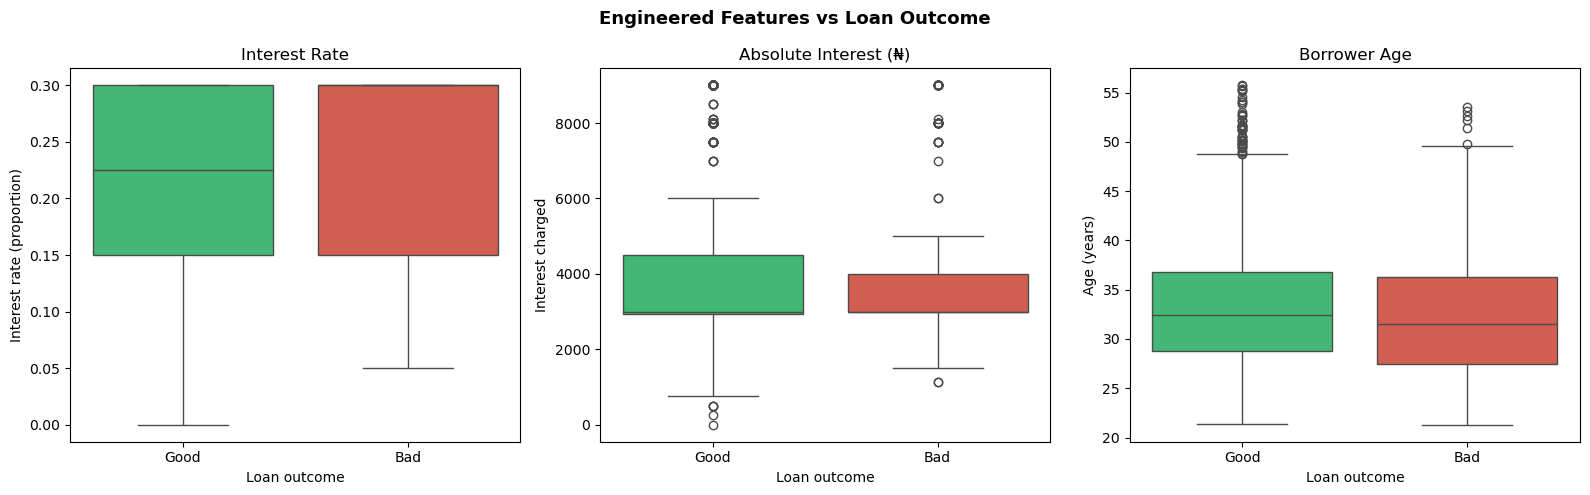

=== interest_rate ===
                count    mean     std   min   25%    50%  75%  max
good_bad_flag                                                     
Bad             952.0  0.2369  0.0730  0.05  0.15  0.300  0.3  0.3
Good           3416.0  0.2124  0.0773  0.00  0.15  0.225  0.3  0.3

=== age_years ===
                count  mean  std   min   25%   50%   75%   max
good_bad_flag                                                 
Bad             713.0  32.2  6.2  21.3  27.5  31.5  36.3  53.5
Good           2556.0  33.1  6.1  21.3  28.8  32.4  36.7  55.7


In [878]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Engineered Features vs Loan Outcome", fontsize=13, fontweight="bold")

sns.boxplot(data=trainperf, x="good_bad_flag", y="interest_rate",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[0])
axes[0].set_title("Interest Rate")
axes[0].set_xlabel("Loan outcome")
axes[0].set_ylabel("Interest rate (proportion)")

sns.boxplot(data=trainperf, x="good_bad_flag", y="interest",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[1])
axes[1].set_title("Absolute Interest (₦)")
axes[1].set_xlabel("Loan outcome")
axes[1].set_ylabel("Interest charged")

sns.boxplot(data=perf_demo, x="good_bad_flag", y="age_years",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[2])
axes[2].set_title("Borrower Age")
axes[2].set_xlabel("Loan outcome")
axes[2].set_ylabel("Age (years)")

plt.tight_layout()
plt.show()

print("=== interest_rate ===")
print(trainperf.groupby("good_bad_flag")["interest_rate"].describe().round(4))
print("\n=== age_years ===")
print(perf_demo.groupby("good_bad_flag")["age_years"].describe().round(1))

**Findings:**
- **Interest rate** — Bad loans have a slightly higher median rate (0.30 vs 0.225) and mean (0.2369 vs 0.2124). Weak but real signal; boxes heavily overlap so it won't separate Good from Bad alone.
- **Absolute interest (₦)** — counterintuitively Good loans have higher absolute interest, because Good borrowers take larger loans. Not a useful feature on its own.
- **Age** — essentially identical distributions (Bad median 31.5 vs Good 32.4). Age carries almost no predictive signal in this dataset.

**Note:** `perf_demo` has ~238 fewer Bad and 853 fewer Good records than `trainperf` after the left join — 22 customers have no demographic record. `age_years` is therefore missing for ~25% of the dataset; use with caution in modeling.

## 11. Categorical Features vs Default

In [881]:
# raw value counts for categorical columns
for col in ["bank_account_type", "bank_name_clients", 
            "employment_status_clients", "level_of_education_clients"]:
    print(col)
    print(perf_demo[col].value_counts(dropna=False).head(10))
    print()

bank_account_type
bank_account_type
Savings    2570
NaN        1099
Other       653
Current      46
Name: count, dtype: int64

bank_name_clients
bank_name_clients
GT Bank         1207
NaN             1099
First Bank       430
Access Bank      328
UBA              267
Zenith Bank      224
Diamond Bank     216
Stanbic IBTC     117
EcoBank          116
FCMB              89
Name: count, dtype: int64

employment_status_clients
employment_status_clients
Permanent        2340
NaN              1099
Unknown           493
Self-Employed     277
Student           111
Unemployed         43
Retired             4
Contract            1
Name: count, dtype: int64

level_of_education_clients
level_of_education_clients
Unknown          2826
NaN              1099
Graduate          321
Secondary          65
Post-Graduate      50
Primary             7
Name: count, dtype: int64



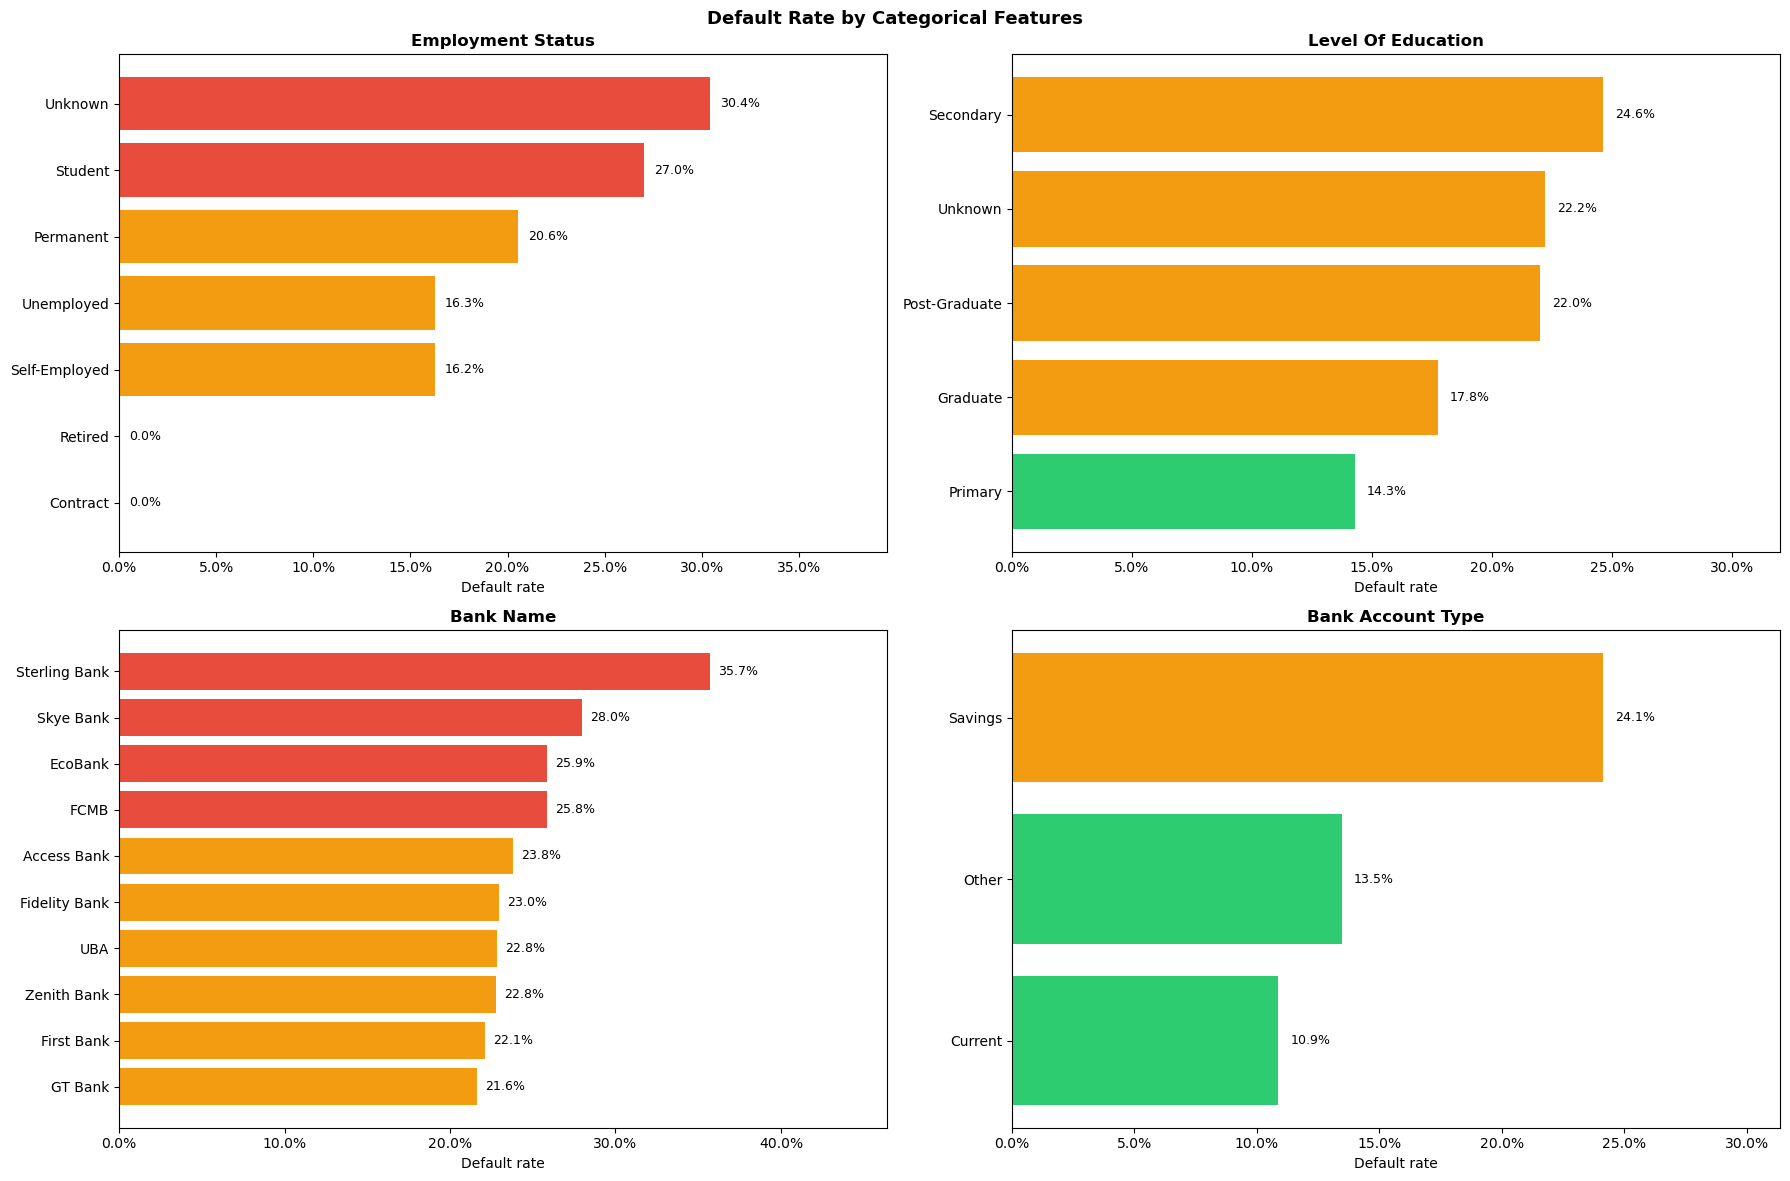


=== employment_status_clients ===
                           default_rate  total_count  bad_count
employment_status_clients                                      
Unknown                           0.304          493        150
Student                           0.270          111         30
Permanent                         0.206         2340        481
Unemployed                        0.163           43          7
Self-Employed                     0.162          277         45
Contract                          0.000            1          0
Retired                           0.000            4          0

=== level_of_education_clients ===
                            default_rate  total_count  bad_count
level_of_education_clients                                      
Secondary                          0.246           65         16
Unknown                            0.222         2826        628
Post-Graduate                      0.220           50         11
Graduate                    

In [882]:
def plot_default_rate(col, ax, top_n=10):
    rates = (perf_demo.groupby(col)["bad_flag"]
             .mean()
             .sort_values(ascending=True)
             .tail(top_n))

    # red = >25% (danger), orange = 15–25% (watch), green = <15% (safe)
    colors = ["#e74c3c" if r >= 0.25 else "#f39c12" if r >= 0.15 else "#2ecc71"
              for r in rates.values]

    bars = ax.barh(rates.index, rates.values, color=colors)
    ax.set_xlim(0, rates.values.max() * 1.3)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(col.replace("_clients", "").replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Default rate")

    for bar, val in zip(bars, rates.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va="center", fontsize=9)

cat_cols = [
    "employment_status_clients",
    "level_of_education_clients",
    "bank_name_clients",
    "bank_account_type"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle("Default Rate by Categorical Features", fontsize=13, fontweight="bold")

for col, ax in zip(cat_cols, axes):
    plot_default_rate(col, ax)

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(perf_demo.groupby(col)["bad_flag"].agg(
        default_rate="mean",
        total_count="count",
        bad_count="sum"
    ).sort_values("default_rate", ascending=False).round(3).to_string())

**Findings:**
- **Employment status** — Unknown (30.4%, n=493) and Student (27%, n=111) are highest risk. Permanent employees (20.5%) are the largest group (n=2,348) and still represent 482 real defaults. Contract and Retired show 0% but with n<5 — statistically meaningless.
- **Education** — Weak signal overall; the spread is only 14.3%–24.6%. Unknown dominates with n=2,834 (86% of records), confirming this column is too sparse to rely on heavily. Higher education does not strongly protect against default.
- **Bank** — Sterling Bank highest at 34.9% but n=43 only. GT Bank is the most reliable estimate (n=1,210, 21.6%). Overall bank default rates cluster tightly between 20–30%, suggesting modest but real predictive value.

## 12. Building the Full Dataset (perf_full)

Merge current loans + aggregated previous loan history + demographics into a single modelling-ready dataframe.

In [885]:
# merge current loans with previous loan aggregates
perf_full = trainperf.merge(agg_prev, on="customerid", how="left")

# merge demographics
perf_full = perf_full.merge(traindemo, on="customerid", how="left")

# age at loan approval
perf_full["age_years"] = (perf_full["approveddate"] - perf_full["birthdate"]).dt.days / 365.25

# days between last closed previous loan and current loan approval
perf_full["prev_last_closeddate"] = pd.to_datetime(perf_full["prev_last_closeddate"])
perf_full["days_since_last_loan"] = (
    perf_full["approveddate"] - perf_full["prev_last_closeddate"]
).dt.days

print(f"perf_full shape: {perf_full.shape}")
print(f"\ndays_since_last_loan:")
print(perf_full["days_since_last_loan"].describe().round(1))
print("\nNegative values (data issue) :", (perf_full["days_since_last_loan"] < 0).sum())
print("NaN (first-time borrowers)   :", perf_full["days_since_last_loan"].isna().sum())

perf_full shape: (4368, 34)

days_since_last_loan:
count    4359.0
mean       13.0
std        44.7
min         0.0
25%         0.0
50%         1.0
75%         8.0
max       526.0
Name: days_since_last_loan, dtype: float64

Negative values (data issue) : 0
NaN (first-time borrowers)   : 9


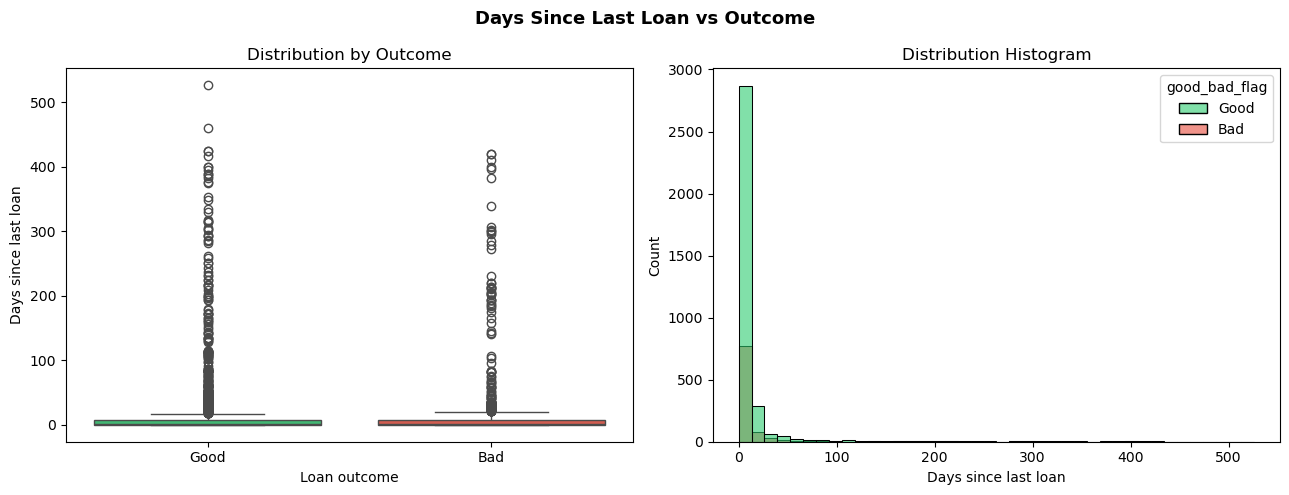

In [889]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Days Since Last Loan vs Outcome", fontsize=13, fontweight="bold")

sns.boxplot(data=perf_full, x="good_bad_flag", y="days_since_last_loan",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[0])
axes[0].set_title("Distribution by Outcome")
axes[0].set_xlabel("Loan outcome")
axes[0].set_ylabel("Days since last loan")

sns.histplot(data=perf_full, x="days_since_last_loan", hue="good_bad_flag",
             palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
             bins=40, ax=axes[1], alpha=0.6)
axes[1].set_title("Distribution Histogram")
axes[1].set_xlabel("Days since last loan")

plt.tight_layout()
plt.show()

**Finding:** `days_since_last_loan` is heavily right-skewed — median = 1 day, 75th percentile = 8 days. Most borrowers take a new loan within a week of closing their last one, reflecting continuous repeat borrowing typical of Nigerian microfinance. The distributions for Good and Bad borrowers are nearly identical, so this feature has weak predictive power in its raw form. A log transformation (`np.log1p`) will be applied before modeling to reduce skew.

## 13. Previous Borrowing Behavior vs Default

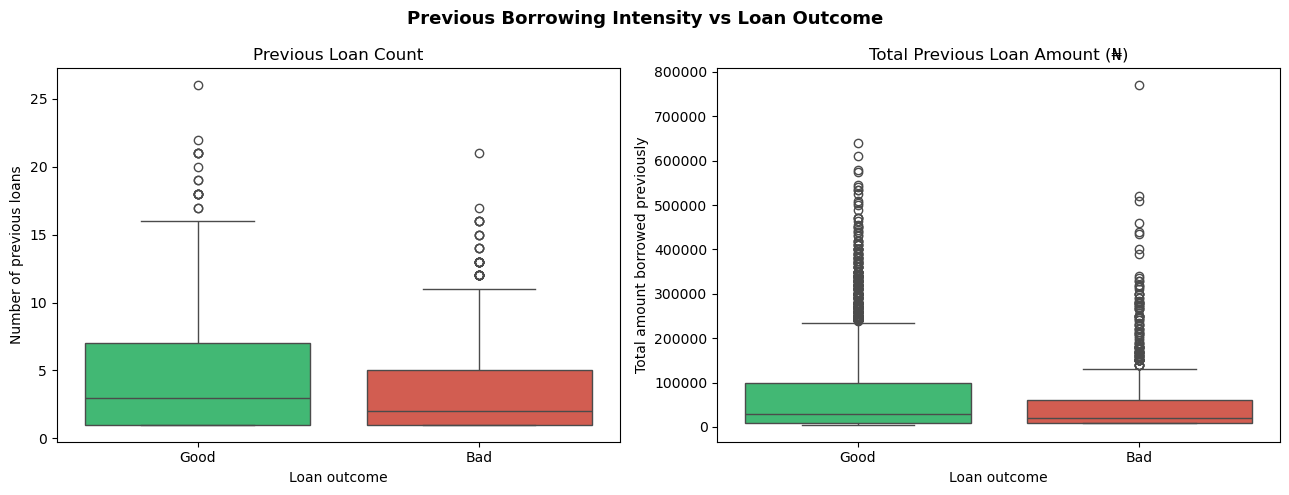

=== prev_loans_count ===
                count  mean  std  min  25%  50%  75%   max
good_bad_flag                                             
Bad             949.0   3.5  3.3  1.0  1.0  2.0  5.0  21.0
Good           3410.0   4.3  3.7  1.0  1.0  3.0  7.0  26.0

=== prev_total_loanamount ===
                count     mean      std      min      25%      50%       75%  \
good_bad_flag                                                                  
Bad             949.0  53728.0  77501.0  10000.0  10000.0  20000.0   60000.0   
Good           3410.0  73036.0  91486.0   5000.0  10000.0  30000.0  100000.0   

                    max  
good_bad_flag            
Bad            770000.0  
Good           640000.0  


In [892]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Previous Borrowing Intensity vs Loan Outcome", fontsize=13, fontweight="bold")

sns.boxplot(data=perf_full, x="good_bad_flag", y="prev_loans_count",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[0])
axes[0].set_title("Previous Loan Count")
axes[0].set_xlabel("Loan outcome")
axes[0].set_ylabel("Number of previous loans")

sns.boxplot(data=perf_full, x="good_bad_flag", y="prev_total_loanamount",
            hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
            legend=False, ax=axes[1])
axes[1].set_title("Total Previous Loan Amount (₦)")
axes[1].set_xlabel("Loan outcome")
axes[1].set_ylabel("Total amount borrowed previously")

plt.tight_layout()
plt.show()

print("=== prev_loans_count ===")
print(perf_full.groupby("good_bad_flag")["prev_loans_count"].describe().round(1))
print("\n=== prev_total_loanamount ===")
print(perf_full.groupby("good_bad_flag")["prev_total_loanamount"].describe().round(0))

**Finding:** Good and Bad borrowers have similar previous loan counts and total amounts — the distributions heavily overlap. This confirms what the correlation heatmap will show: `prev_loans_count` and `prev_total_loanamount` are more correlated with loan size than with default risk. Borrowing more historically does not by itself predict default; *how* you repaid matters far more than *how much* you borrowed.

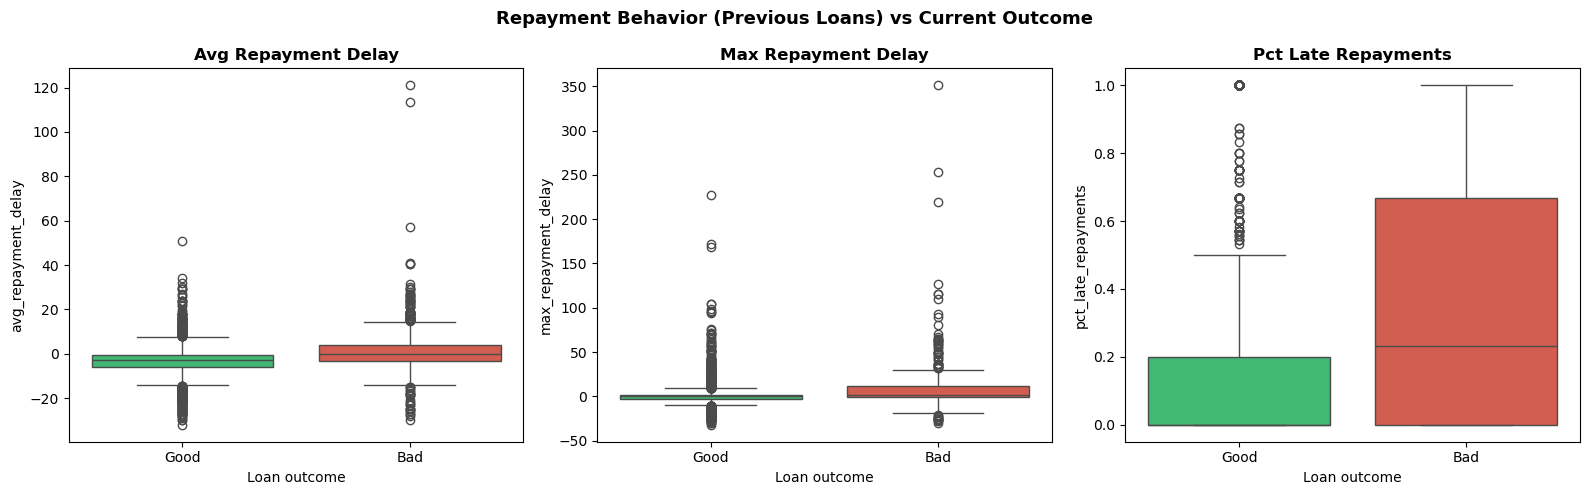


=== avg_repayment_delay ===
                count  mean    std   min  25%   50%   75%     max
good_bad_flag                                                    
Bad             949.0  0.92  10.18 -30.0 -3.4 -0.12  3.85  121.00
Good           3410.0 -3.39   6.11 -32.0 -6.0 -3.00 -0.50   50.67

=== max_repayment_delay ===
                count  mean    std   min  25%  50%   75%    max
good_bad_flag                                                  
Bad             949.0  7.88  21.84 -30.0 -1.0  2.0  12.0  351.0
Good           3410.0  1.39  12.27 -32.0 -3.0  0.0   2.0  227.0

=== pct_late_repayments ===
                count  mean   std  min  25%   50%   75%  max
good_bad_flag                                               
Bad             949.0  0.35  0.38  0.0  0.0  0.23  0.67  1.0
Good           3410.0  0.14  0.26  0.0  0.0  0.00  0.20  1.0


In [894]:
repay_cols = ["avg_repayment_delay", "max_repayment_delay", "pct_late_repayments"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Repayment Behavior (Previous Loans) vs Current Outcome",
             fontsize=13, fontweight="bold")

for col, ax in zip(repay_cols, axes):
    sns.boxplot(data=perf_full, x="good_bad_flag", y=col,
                hue="good_bad_flag", palette={"Good": "#2ecc71", "Bad": "#e74c3c"},
                legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Loan outcome")

plt.tight_layout()
plt.show()

for col in repay_cols:
    print(f"\n=== {col} ===")
    print(perf_full.groupby("good_bad_flag")[col].describe().round(2))

**Finding:** This is the clearest separation in the entire dataset.
- **`pct_late_repayments`** — Good borrowers median: 0.00 (majority never late); Bad borrowers median: 0.23 (nearly 1 in 4 previous loans paid late). Mean doubles from 0.14 to 0.35.
- **`avg_repayment_delay`** — Good borrowers average **-3.39 days** (pay early); Bad borrowers average **+0.89 days** (barely on time or late).
- **`max_repayment_delay`** — Good median: 0 days; Bad median: 2 days.

All three repayment features are among the strongest predictors in this dataset and should be prioritized in modeling.

## 14. Geographic Analysis

In [898]:
# check GPS data quality before plotting
print("GPS null values:")
print(perf_full[["longitude_gps", "latitude_gps"]].isnull().sum())
print("\nGPS ranges:")
print(perf_full[["longitude_gps", "latitude_gps"]].describe().round(4))

GPS null values:
longitude_gps    1099
latitude_gps     1099
dtype: int64

GPS ranges:
       longitude_gps  latitude_gps
count      3269.0000     3269.0000
mean          4.5310        7.2904
std           7.9255        3.2696
min        -118.2470      -33.8688
25%           3.3548        6.4736
50%           3.5842        6.6257
75%           6.4399        7.4267
max         151.2093       71.2281


**Data quality issue:** Coordinates include clearly incorrect entries — longitude -118.247 (Los Angeles), latitude -33.869 (Sydney), latitude 71.228 (Arctic Norway). These are GPS input errors. We filter to Nigeria's bounding box before plotting.

Valid GPS rows: 3,237 out of 4,368


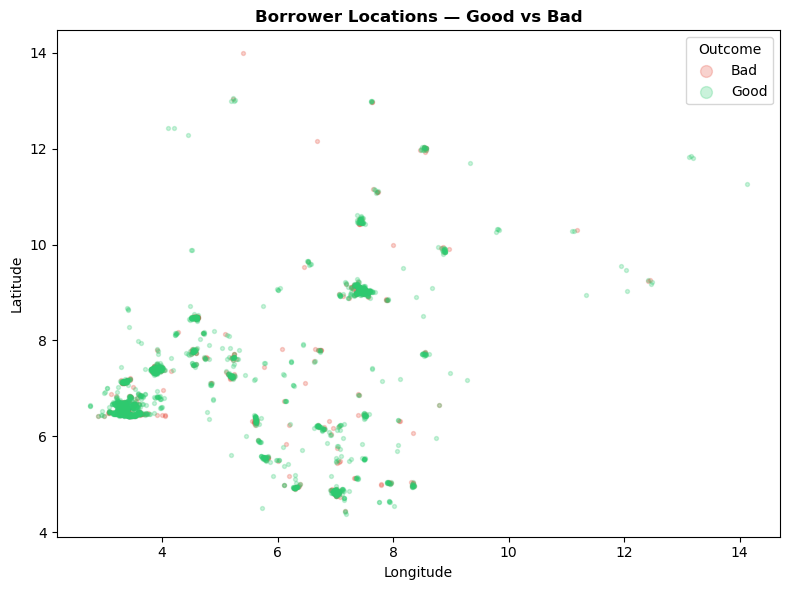


=== Default rate by region ===
         default_rate  total_count  bad_count
region                                       
West            0.207         2160        448
Central         0.234          954        223
East            0.244          123         30


In [901]:
LAT_MIN, LAT_MAX = 4.0, 14.0
LON_MIN, LON_MAX = 2.7, 15.0

gps_clean = perf_full[
    perf_full["latitude_gps"].between(LAT_MIN, LAT_MAX) &
    perf_full["longitude_gps"].between(LON_MIN, LON_MAX)
].copy()

print(f"Valid GPS rows: {len(gps_clean):,} out of {len(perf_full):,}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Borrower Locations — Good vs Bad", fontweight="bold")

colors = {"Good": "#2ecc71", "Bad": "#e74c3c"}
for flag, group in gps_clean.groupby("good_bad_flag"):
    ax.scatter(group["longitude_gps"], group["latitude_gps"],
               c=colors[flag], alpha=0.25, s=8, label=flag)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Outcome", markerscale=3)
plt.tight_layout()
plt.show()

gps_clean["region"] = pd.cut(
    gps_clean["longitude_gps"],
    bins=[2.7, 5.0, 8.0, 15.0],
    labels=["West", "Central", "East"]
)

print("\n=== Default rate by region ===")
print(gps_clean.groupby("region", observed=True)["bad_flag"].agg(
    default_rate="mean",
    total_count="count",
    bad_count="sum"
).round(3))

**Finding:** The majority of borrowers are concentrated in Lagos (West region, longitude ~3.3–4.0). Bad borrowers are distributed evenly across the map with no clear geographic clustering. Regional default rates — West 20.7%, Central 23.3%, East 25.0% — show only a mild gradient, and the East sample (n=124) is too small to be reliable. GPS coordinates are unlikely to be strong model features on their own.

## 15. Full Feature Correlation Heatmap

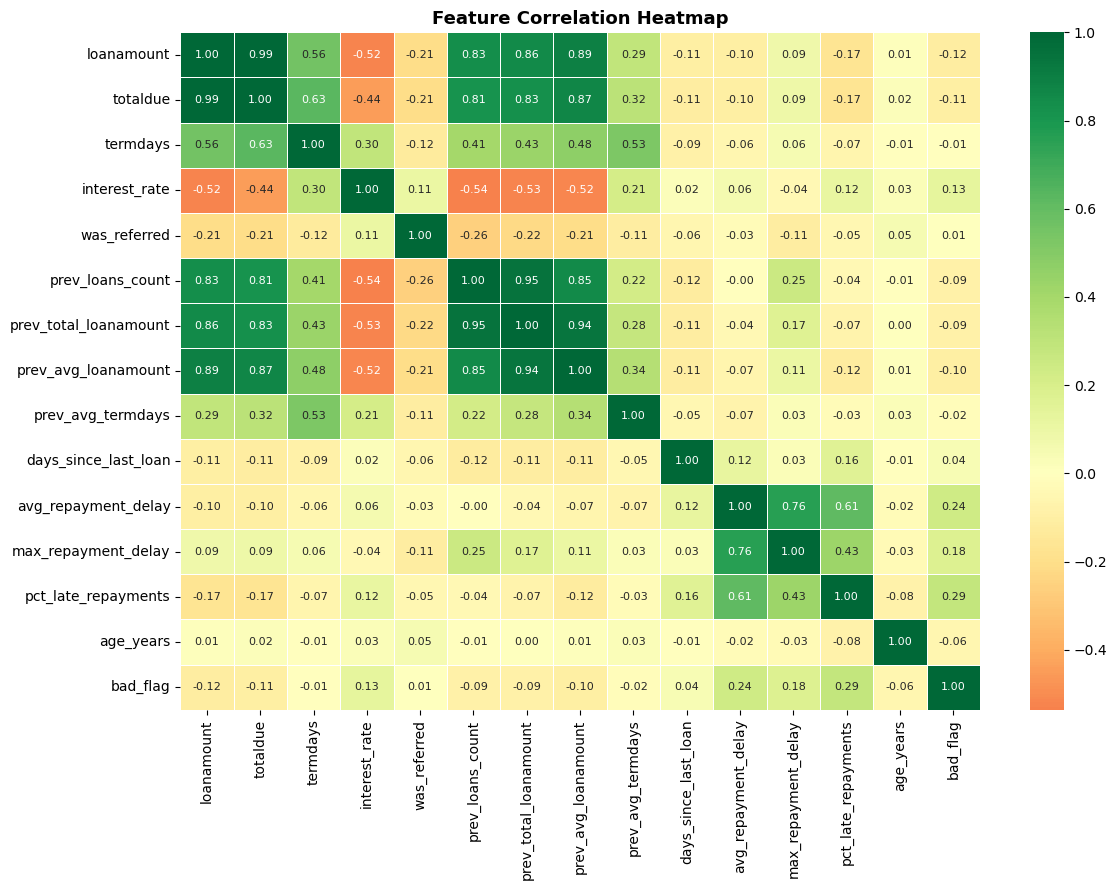


=== Correlation with bad_flag (target) ===
pct_late_repayments      0.286
avg_repayment_delay      0.240
max_repayment_delay      0.177
interest_rate            0.131
days_since_last_loan     0.044
was_referred             0.010
termdays                -0.005
prev_avg_termdays       -0.016
age_years               -0.061
prev_total_loanamount   -0.090
prev_loans_count        -0.090
prev_avg_loanamount     -0.104
totaldue                -0.108
loanamount              -0.115
Name: bad_flag, dtype: float64


In [904]:
numeric_features = [
    "loanamount", "totaldue", "termdays", "interest_rate",
    "was_referred", "prev_loans_count", "prev_total_loanamount",
    "prev_avg_loanamount", "prev_avg_termdays", "days_since_last_loan",
    "avg_repayment_delay", "max_repayment_delay", "pct_late_repayments",
    "age_years", "bad_flag"
]

corr = perf_full[numeric_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Correlation with bad_flag (target) ===")
print(corr["bad_flag"].drop("bad_flag").sort_values(ascending=False).round(3))

**Findings:**

**Correlation with target (`bad_flag`):**
- `pct_late_repayments` (+0.29) — strongest single predictor
- `avg_repayment_delay` (+0.24) — strong
- `max_repayment_delay` (+0.18) — moderate
- `interest_rate` (+0.13) — weak but present
- All others below 0.10 — negligible on their own

**Multicollinearity warning:**
`loanamount`, `totaldue`, `prev_total_loanamount`, `prev_avg_loanamount`, and `prev_loans_count` are all intercorrelated at 0.83–0.99. At modeling time, keep only `loanamount` + `prev_loans_count` and drop the rest to avoid redundancy.

`avg_repayment_delay` and `max_repayment_delay` correlate at 0.76 — fairly redundant, likely only need one at modeling time.

## 16. EDA Summary

| Feature | Signal Strength | Notes |
|---|---|---|
| `pct_late_repayments` | ⭐⭐⭐ Strong | Best single predictor — median 0.00 (Good) vs 0.23 (Bad) |
| `avg_repayment_delay` | ⭐⭐⭐ Strong | Good borrowers pay 3.4 days early on average |
| `max_repayment_delay` | ⭐⭐ Moderate | Correlated with avg_delay (0.76) — may only need one |
| `interest_rate` | ⭐⭐ Moderate | Weak separation but consistent direction |
| `employment_status` | ⭐⭐ Moderate | Unknown & Student highest risk (>25%) |
| `bank_name` | ⭐ Weak | Rates cluster 20–30%, modest signal |
| `was_referred` | ⭐ Weak | To be confirmed at modeling time |
| `age_years` | ⭐ Weak | Near-zero correlation with target |
| `days_since_last_loan` | ⭐ Weak | Skewed; log transform recommended before modeling |
| `GPS / region` | ⭐ Weak | No clear geographic clustering of defaults |
| `approval_lag_days` | ✗ Drop | Near-zero variance — same-day approvals universally |
| `interest` (absolute ₦) | ✗ Drop | Redundant with `loanamount` + `interest_rate` |
| `prev_total_loanamount` | ✗ Drop | Highly collinear with `loanamount` (0.86) |
| `prev_avg_loanamount` | ✗ Drop | Highly collinear with `loanamount` (0.89) |